<a href="https://colab.research.google.com/github/Rony-pat/Clases/blob/main/Tarea_20_Aprendizaje_supervisado_%E2%80%93_An%C3%A1lisis_de_regresi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
marketing = pd.read_csv('datos_marketing.csv')

# b) Realizar una exploración inicial de los datos
print(marketing.head())  # Muestra las primeras filas del DataFrame
print(marketing.info())  # Información sobre las columnas y tipos de datos
print(marketing.describe())  # Estadísticas descriptivas de las variables numéricas


      Gasto_TV  Gasto_Radio  Gasto_Digital       Ventas
0  3195.254016  1516.724805     605.334647  2261.964648
1  3860.757465   905.011960    1105.246535  2549.022146
2  3411.053504  1602.791033     691.077391  2035.921506
3  3179.532732  1943.282818     433.484781  2150.487303
4  2694.619197   873.129715     232.082347   953.634528
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gasto_TV       100 non-null    float64
 1   Gasto_Radio    100 non-null    float64
 2   Gasto_Digital  100 non-null    float64
 3   Ventas         100 non-null    float64
dtypes: float64(4)
memory usage: 3.2 KB
None
          Gasto_TV  Gasto_Radio  Gasto_Digital       Ventas
count   100.000000   100.000000     100.000000   100.000000
mean   2891.175358  1292.122634     862.521579  1949.573421
std    1159.016061   417.154481     394.160745   683.051287
min    1018.

In [2]:
from sklearn.model_selection import train_test_split

# Seleccionar las características (Gasto en TV, Radio y Digital) y la variable objetivo (Ventas)
X = marketing[['Gasto_TV', 'Gasto_Radio', 'Gasto_Digital']]
y = marketing['Ventas']

# Dividir los datos en conjunto de entrenamiento (70%) y conjunto de prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Mostrar las dimensiones de los conjuntos
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(70, 3) (30, 3) (70,) (30,)


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Crear y entrenar el modelo de regresión lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_lineal = modelo_lineal.predict(X_test)

# Calcular el Error Cuadrático Medio (MSE) y el coeficiente de determinación (R2)
mse_lineal = mean_squared_error(y_test, y_pred_lineal)
r2_lineal = r2_score(y_test, y_pred_lineal)

# Mostrar los resultados
print(f"Regresión Lineal - MSE: {mse_lineal}, R2: {r2_lineal}")


Regresión Lineal - MSE: 240257.02921829963, R2: 0.45085885766263234


In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Probar diferentes grados de polinomio (por ejemplo, del 2 al 5)
for grado in range(2, 6):
    modelo_polinomial = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo_polinomial.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred_polinom = modelo_polinomial.predict(X_test)

    # Calcular el MSE y R2 para el modelo polinomial
    mse_polinom = mean_squared_error(y_test, y_pred_polinom)
    r2_polinom = r2_score(y_test, y_pred_polinom)

    # Mostrar los resultados
    print(f"Regresión Polinomial (grado {grado}) - MSE: {mse_polinom}, R2: {r2_polinom}")


Regresión Polinomial (grado 2) - MSE: 285614.0405609962, R2: 0.34718904578334586
Regresión Polinomial (grado 3) - MSE: 364683.2281639479, R2: 0.16646532608513653
Regresión Polinomial (grado 4) - MSE: 1214982.0773789668, R2: -1.7770119694816224
Regresión Polinomial (grado 5) - MSE: 1438038.3689150808, R2: -2.2868384130125774


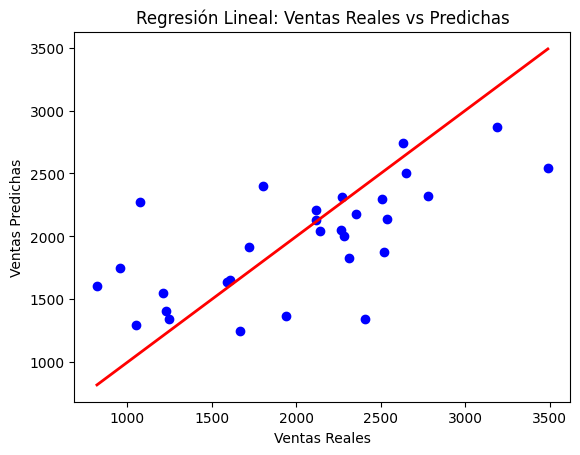

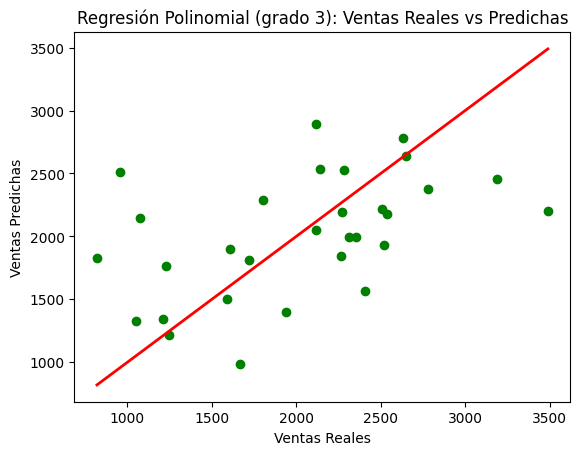

In [5]:
import matplotlib.pyplot as plt

# Gráfico para la Regresión Lineal
plt.scatter(y_test, y_pred_lineal, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Regresión Lineal: Ventas Reales vs Predichas')
plt.xlabel('Ventas Reales')
plt.ylabel('Ventas Predichas')
plt.show()

# Gráfico para la Regresión Polinomial de mejor rendimiento
grado_optimo = 3  # Puedes ajustar el grado óptimo tras observar los resultados
modelo_polinomial_optimo = make_pipeline(PolynomialFeatures(grado_optimo), LinearRegression())
modelo_polinomial_optimo.fit(X_train, y_train)
y_pred_optimo = modelo_polinomial_optimo.predict(X_test)

plt.scatter(y_test, y_pred_optimo, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title(f'Regresión Polinomial (grado {grado_optimo}): Ventas Reales vs Predichas')
plt.xlabel('Ventas Reales')
plt.ylabel('Ventas Predichas')
plt.show()


1. ¿Cuál modelo tiene mejor rendimiento en términos de MSE y R²?
El modelo de regresión lineal tiene un mejor rendimiento en comparación con los modelos de regresión polinomial en términos de Error Cuadrático Medio (MSE) y coeficiente de determinación (R²)

2. ¿Qué observas sobre la relación entre las variables y las ventas?
La relación entre el gasto en publicidad (TV, Radio y Digital) y las ventas es moderada, como lo indica el valor de R² de 0.4509 en el modelo lineal. Esto sugiere que aproximadamente el 45.09% de la variabilidad en las ventas puede ser explicada por las variables independientes (gastos publicitarios). Sin embargo, hay un 40.91% de variabilidad que no se explica, lo que sugiere que otros factores no considerados en el modelo podrían influir en las ventas.

3. ¿Cuál es el grado óptimo del modelo polinomial?
El modelo lineal (grado 1).